   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 68.8 MB/s eta 0:00:00:00:0100:01


2026-07-09 20:09:04.289749: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783627744.595354      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783627744.681185      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783627745.423572      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783627745.423652      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783627745.423657      57 computation_placer.cc:177] computation placer alr

Database ready: 20871 panels (17741 train / 3130 val).
Generating train and validation datasets...


[I 2026-07-09 20:09:33,614] A new study created in memory with name: no-name-0ca65021-039a-43cd-9324-8e82a03f81f3


Train points: 100000 | Val points: 16000

Starting Bayesian hyperparameter search (Optuna / TPE)...


/usr/local/lib/python3.12/dist-packages/optuna/progress_bar.py:47: ExperimentalWarning: Progress bar is experimental (supported from v1.2.0). The interface can change in the future.
  self._init_valid()


  0%|          | 0/25 [00:00<?, ?it/s]

2026-07-09 20:09:33.641047: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


[I 2026-07-09 20:10:52,815] Trial 0 finished with value: 0.00030297797347884626 and parameters: {'units1': 224, 'units2': 256, 'units3': 96, 'learning_rate': 0.0015751320499779737, 'decay_rate': 0.871842609661941, 'decay_steps': 400, 'batch_size': 1024, 'phys_weight_final': 0.005471975564178365, 'warmup_end': 20, 'ramp_end': 37}. Best is trial 0 with value: 0.00030297797347884626.
[I 2026-07-09 20:11:35,245] Trial 1 finished with value: 0.0050242398283444345 and parameters: {'units1': 160, 'units2': 64, 'units3': 32, 'learning_rate': 0.0004059611610484307, 'decay_rate': 0.9234659004285133, 'decay_steps': 900, 'batch_size': 1024, 'phys_weight_final': 0.024899438865017734, 'warmup_end': 12, 'ramp_end': 36}. Best is trial 0 with value: 0.00030297797347884626.
[I 2026-07-09 20:12:24,581] Trial 2 finished with value: 0.02601414918899536 and parameters: {'units1': 128, 'units2': 160, 'units3': 80, 'learning_rate': 0.0001238513729886094, 'decay_rate': 0.9350562792662014, 'decay_steps': 400, '

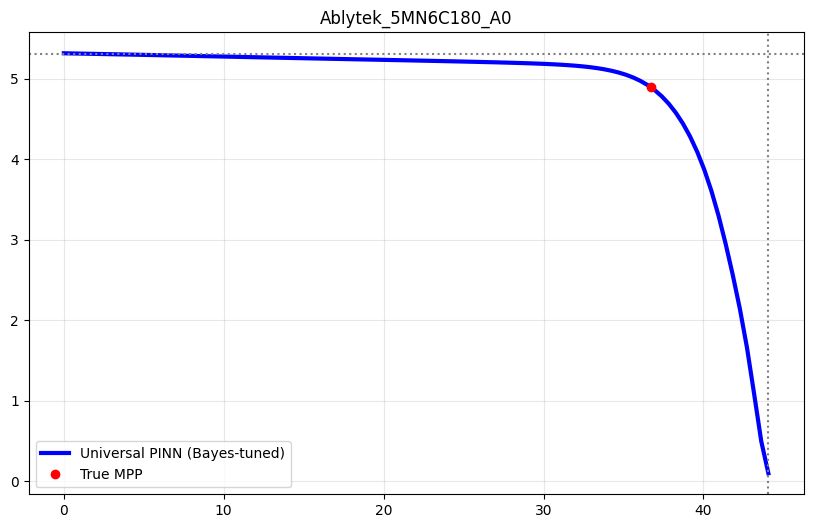

/tmp/ipykernel_57/2421165094.py:351: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


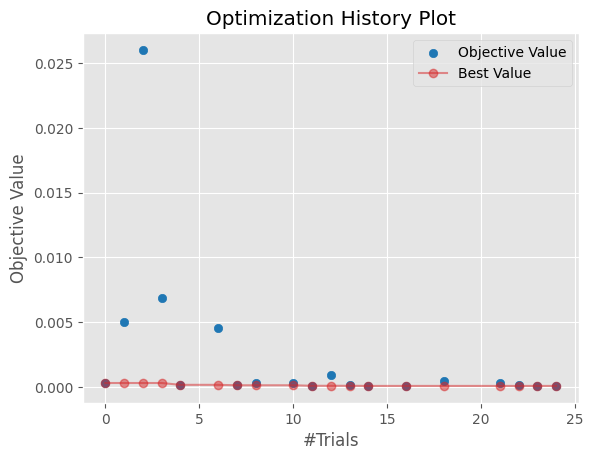

/tmp/ipykernel_57/2421165094.py:353: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


(Skipping Optuna plots: setting an array element with a sequence. The requested array would exceed the maximum number of dimension of 1.)


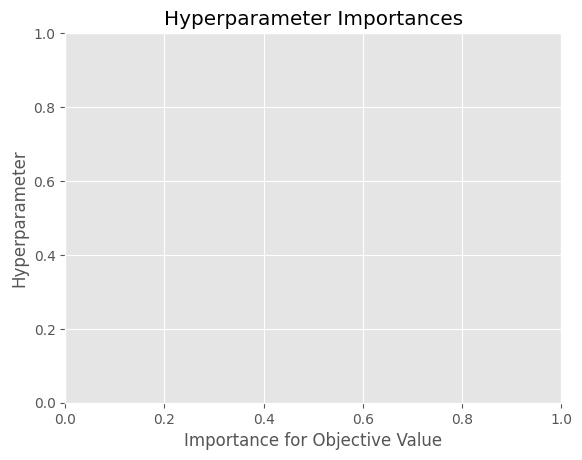

In [1]:
!pip install pvlib optuna

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pvlib
from pvlib import pvsystem
from sklearn.preprocessing import RobustScaler
import optuna
from optuna.samplers import TPESampler

pd.options.mode.chained_assignment = None

# =============================================================================
# 1. DATABASE
# =============================================================================
all_modules = pvlib.pvsystem.retrieve_sam('CECMod').T
df_db = all_modules[all_modules['Technology'].str.contains('Si', na=False)].copy()

dna_cols = ['alpha_sc', 'a_ref', 'I_L_ref', 'I_o_ref', 'R_s', 'R_sh_ref', 'N_s']
for col in dna_cols + ['V_oc_ref', 'I_sc_ref', 'V_mp_ref', 'I_mp_ref']:
    df_db[col] = pd.to_numeric(df_db[col], errors='coerce')

df_db = df_db[
    (df_db['I_o_ref'] > 1e-15) & (df_db['a_ref'] > 0.5) &
    (df_db['R_sh_ref'] > 10.0) & (df_db['I_sc_ref'] > 0.5) &
    (df_db['V_oc_ref'] > 10.0)
].dropna(subset=dna_cols)

df_db['I_o_ref_log'] = np.log10(df_db['I_o_ref'])
df_db['R_sh_ref_log'] = np.log10(df_db['R_sh_ref'])

fit_cols = ['alpha_sc', 'a_ref', 'I_L_ref', 'I_o_ref_log', 'R_s', 'R_sh_ref_log', 'N_s']

# --- Panel-level split BEFORE fitting the scaler, so validation panels are truly held out ---
rng = np.random.default_rng(42)
shuffled_idx = rng.permutation(len(df_db))
n_val_panels = max(20, int(0.15 * len(df_db)))
val_panel_idx = shuffled_idx[:n_val_panels]
train_panel_idx = shuffled_idx[n_val_panels:]

df_train_panels = df_db.iloc[train_panel_idx]
df_val_panels = df_db.iloc[val_panel_idx]

dna_scaler = RobustScaler()
dna_scaler.fit(df_train_panels[fit_cols])  # fit only on training panels, avoid leakage

print(f"Database ready: {len(df_db)} panels "
      f"({len(df_train_panels)} train / {len(df_val_panels)} val).")

# =============================================================================
# 2. DATA GENERATOR
# =============================================================================
def generate_pinn_data(source_df, n_panels=2500, pts=50, seed=None):
    X, y = [], []
    local_rng = np.random.default_rng(seed)
    indices = local_rng.choice(len(source_df), n_panels, replace=True)

    for idx in indices:
        row = source_df.iloc[idx]

        dna_vals = [row[c] for c in fit_cols]
        dna_df = pd.DataFrame([dna_vals], columns=fit_cols)
        dna_norm = dna_scaler.transform(dna_df)[0]

        G = local_rng.uniform(200, 1100, pts)
        T_c = local_rng.uniform(15, 75, pts)

        try:
            IL, Io, Rs, Rsh, nNsVth = pvsystem.calcparams_desoto(
                G, T_c, row['alpha_sc'], row['a_ref'], row['I_L_ref'],
                row['I_o_ref'], row['R_sh_ref'], row['R_s']
            )
            V_norm_axis = np.linspace(0, 1.0, pts)
            I_raw = pvsystem.i_from_v(V_norm_axis * row['V_oc_ref'], IL, Io, Rs, Rsh, nNsVth)

            for j in range(pts):
                if not np.isnan(I_raw[j]):
                    X.append([
                        G[j] / 1000.0, (T_c[j] - 25.0) / 100.0, V_norm_axis[j]
                    ] + dna_norm.tolist() + [
                        row['V_oc_ref'] / 50.0, row['I_sc_ref'] / 10.0
                    ])
                    y.append(max(0, I_raw[j] / row['I_sc_ref']))
        except Exception:
            continue

    return np.array(X, 'float32'), np.array(y, 'float32').reshape(-1, 1)


print("Generating train and validation datasets...")
X_train, y_train = generate_pinn_data(df_train_panels, n_panels=2500, pts=40, seed=1)
X_val, y_val = generate_pinn_data(df_val_panels, n_panels=400, pts=40, seed=2)
print(f"Train points: {len(X_train)} | Val points: {len(X_val)}")

# =============================================================================
# 3. MODEL / TRAIN-STEP FACTORY (parameterized so Optuna can control it)
# =============================================================================
def build_model(units1, units2, units3):
    return keras.Sequential([
        layers.InputLayer(shape=(12,)),
        layers.Dense(units1, activation='swish'),
        layers.Dense(units2, activation='swish'),
        layers.Dense(units3, activation='swish'),
        layers.Dense(1, activation='linear')  # linear output is crucial for PINNs
    ])


def make_train_step(model, optimizer):
    @tf.function
    def train_step(x, y_true, phys_weight):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(x)
            y_pred = model(x, training=True)

            grads_input = tape.gradient(y_pred, x)
            dI_dV = grads_input[:, 2:3]  # voltage is feature index 2

            loss_data = tf.reduce_mean(tf.square(y_true - y_pred))
            loss_monotonic = tf.reduce_mean(tf.square(tf.nn.relu(dI_dV)))

            total_loss = loss_data + (phys_weight * loss_monotonic)

        grads_weights = tape.gradient(total_loss, model.trainable_variables)
        del tape
        optimizer.apply_gradients(zip(grads_weights, model.trainable_variables))
        return loss_data, loss_monotonic

    return train_step


def phys_weight_for_epoch(epoch, warmup_end, ramp_end, final_weight):
    """Adaptive physics weight schedule, now tunable instead of hardcoded."""
    if epoch < warmup_end:
        return 0.0
    elif epoch < ramp_end:
        return final_weight * 0.2
    else:
        return final_weight


def _compute_val_metrics(model, X_va, y_va, monotonic_weight=0.05):
    """Returns (data_mse, monotonic_violation, combined_score) on validation data.

    data_mse: plain MSE between predicted and true normalized current.
    monotonic_violation: mean squared magnitude of any positive dI/dV slope
        (should be ~0 for a physically valid I-V curve; I always decreases
        with V, so dI/dV should be <= 0 everywhere).
    combined_score: what Optuna actually optimizes/prunes on, so a model
        that fits well but has visible non-monotonic wiggles is not treated
        as "the best" over one that fits almost as well with a clean curve.
    """
    X_va_tf = tf.convert_to_tensor(X_va, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(X_va_tf)
        y_pred = model(X_va_tf, training=False)
    grads = tape.gradient(y_pred, X_va_tf)
    dI_dV = grads[:, 2:3]  # voltage is feature index 2

    monotonic_violation = float(tf.reduce_mean(tf.square(tf.nn.relu(dI_dV))))
    data_mse = float(np.mean(np.square(y_va - y_pred.numpy())))
    combined_score = data_mse + monotonic_weight * monotonic_violation

    return data_mse, monotonic_violation, combined_score


# How heavily monotonicity violations count against the validation score.
# Scaled so that a "clean" model (near-zero violation) barely differs from
# pure data MSE, but a model with visible non-monotonic wiggles is penalized.
VAL_MONOTONIC_WEIGHT = 0.05


def train_model(params, epochs, X_tr, y_tr, X_va=None, y_va=None, verbose=False,
                 trial=None, report_every=5):
    """Builds, trains, and returns (model, val_metrics).

    val_metrics is a dict {'data_mse', 'monotonic_violation', 'combined_score'}
    (or None if no validation data is provided).

    If `trial` (an optuna.Trial) is passed, the combined score is computed and
    reported every `report_every` epochs so Optuna's pruner can actually cut
    unpromising trials short instead of only seeing one score at the very end.
    """
    model = build_model(params['units1'], params['units2'], params['units3'])

    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=params['learning_rate'],
        decay_steps=params['decay_steps'],
        decay_rate=params['decay_rate'],
        staircase=True)
    optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)
    train_step = make_train_step(model, optimizer)

    dataset = tf.data.Dataset.from_tensor_slices((X_tr, y_tr)) \
        .shuffle(100000).batch(params['batch_size'])

    for epoch in range(epochs):
        p_w = phys_weight_for_epoch(
            epoch, params['warmup_end'], params['ramp_end'], params['phys_weight_final']
        )
        l_d, l_p = [], []
        for xb, yb in dataset:
            d, p = train_step(xb, yb, tf.constant(p_w, dtype=tf.float32))
            l_d.append(d); l_p.append(p)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch+1:<4} | data_loss={np.mean(l_d):.6f} "
                  f"| phys_loss={np.mean(l_p):.6f} | phys_w={p_w:.3f}")

        # --- Mid-training pruning check ---
        is_last_epoch = (epoch == epochs - 1)
        if trial is not None and X_va is not None:
            if ((epoch + 1) % report_every == 0) or is_last_epoch:
                _, _, interim_score = _compute_val_metrics(
                    model, X_va, y_va, monotonic_weight=VAL_MONOTONIC_WEIGHT
                )
                trial.report(interim_score, step=epoch)
                if trial.should_prune():
                    raise optuna.TrialPruned(
                        f"Pruned at epoch {epoch+1} (combined_score={interim_score:.6f})"
                    )

    val_metrics = None
    if X_va is not None:
        data_mse, monotonic_violation, combined_score = _compute_val_metrics(
            model, X_va, y_va, monotonic_weight=VAL_MONOTONIC_WEIGHT
        )
        val_metrics = {
            'data_mse': data_mse,
            'monotonic_violation': monotonic_violation,
            'combined_score': combined_score,
        }
        if verbose:
            print(f"  val: data_mse={data_mse:.6f} | monotonic_violation={monotonic_violation:.6f} "
                  f"| combined_score={combined_score:.6f}")

    return model, val_metrics

# =============================================================================
# 4. BAYESIAN OPTIMIZATION (Optuna, TPE sampler)
# =============================================================================
SEARCH_EPOCHS = 35   # short budget per trial to keep the search cheap
N_TRIALS = 25         # number of Bayesian-optimization trials

def objective(trial):
    params = {
        'units1': trial.suggest_int('units1', 64, 512, step=32),          # was 384 max -> widened
        'units2': trial.suggest_int('units2', 32, 256, step=32),
        'units3': trial.suggest_int('units3', 16, 128, step=16),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),  # was 5e-3 max -> widened
        'decay_rate': trial.suggest_float('decay_rate', 0.85, 0.99),
        'decay_steps': trial.suggest_int('decay_steps', 100, 2000, step=100),  # was 300 min -> widened
        'batch_size': trial.suggest_categorical('batch_size', [512, 1024, 2048, 4096]),
        'phys_weight_final': trial.suggest_float('phys_weight_final', 0.005, 0.4, log=True),  # was 0.2 max -> widened
        'warmup_end': trial.suggest_int('warmup_end', 5, 20),
        'ramp_end': trial.suggest_int('ramp_end', 20, 40),
    }
    # keep the schedule sane: ramp_end must exceed warmup_end
    if params['ramp_end'] <= params['warmup_end']:
        params['ramp_end'] = params['warmup_end'] + 5

    _, val_metrics = train_model(
        params, epochs=SEARCH_EPOCHS,
        X_tr=X_train, y_tr=y_train, X_va=X_val, y_va=y_val,
        verbose=False,
        trial=trial,          # enables mid-training reporting + pruning
        report_every=5,       # check every 5 epochs instead of only at the end
    )

    return val_metrics['combined_score']


print("\nStarting Bayesian hyperparameter search (Optuna / TPE)...")
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,    # don't prune until 5 trials have fully completed
        n_warmup_steps=10,     # don't prune before epoch 10 within a trial
        interval_steps=5,      # matches report_every in train_model
    )
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\nBest trial:")
print(f"  Validation combined score: {study.best_value:.6f}  "
      f"(= data_mse + {VAL_MONOTONIC_WEIGHT} * monotonic_violation)")
print("  Params:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

# =============================================================================
# 5. FINAL TRAINING WITH BEST HYPERPARAMETERS (full epoch budget)
# =============================================================================
best_params = dict(study.best_params)
if best_params['ramp_end'] <= best_params['warmup_end']:
    best_params['ramp_end'] = best_params['warmup_end'] + 5

print("\nRetraining final model with best hyperparameters (150 epochs)...")
model, final_val_metrics = train_model(
    best_params, epochs=150,
    X_tr=X_train, y_tr=y_train, X_va=X_val, y_va=y_val,
    verbose=True
)
print(f"\nFinal held-out validation:")
print(f"  data_mse             = {final_val_metrics['data_mse']:.6f}")
print(f"  monotonic_violation  = {final_val_metrics['monotonic_violation']:.6f}")
print(f"  combined_score       = {final_val_metrics['combined_score']:.6f}")

# =============================================================================
# 6. TEST / VISUALIZE
# =============================================================================
def test_panel(panel_name=None):
    if panel_name is not None and panel_name in df_db.index:
        row = df_db.loc[panel_name]
    else:
        row = df_db.sample(1, random_state=None).iloc[0]
        panel_name = row.name

    dna_vals = [row[c] for c in fit_cols]
    dna_df = pd.DataFrame([dna_vals], columns=fit_cols)
    dna_norm = dna_scaler.transform(dna_df)[0]

    v_sweep = np.linspace(0, 1.0, 100)
    X_test = []
    for v in v_sweep:
        X_test.append([1.0, 0.0, v] + dna_norm.tolist() +
                       [row['V_oc_ref'] / 50.0, row['I_sc_ref'] / 10.0])

    y_pred = model.predict(np.array(X_test, dtype='float32'), verbose=0)
    I_pred = y_pred.flatten() * row['I_sc_ref']

    plt.figure(figsize=(10, 6))
    plt.plot(v_sweep * row['V_oc_ref'], I_pred, label='Universal PINN (Bayes-tuned)',
              color='blue', lw=3)
    plt.plot(row['V_mp_ref'], row['I_mp_ref'], 'ro', label='True MPP')
    plt.axhline(row['I_sc_ref'], color='gray', ls=':')
    plt.axvline(row['V_oc_ref'], color='gray', ls=':')
    plt.title(f"{panel_name}")
    plt.legend(); plt.grid(True, alpha=0.3); plt.show()


print("\nPlotting results on a random held-out panel...")
test_panel("Ablytek_5MN6C180_A0")  # picks a random panel; pass a specific index name if you want a fixed one

# Optional: inspect the optimization history
try:
    optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.show()
    optuna.visualization.matplotlib.plot_param_importances(study)
    plt.show()
except Exception as e:
    print(f"(Skipping Optuna plots: {e})")

In [2]:
!pip install pvlib
import pvlib
from pvlib import pvsystems
!pip list | grep -E 'numpy|pandas|tensorflow|keras|matplotlib|pvlib|scikit-learn|pvsystem'
!python --version

ImportError: cannot import name 'pvsystems' from 'pvlib' (/usr/local/lib/python3.12/dist-packages/pvlib/__init__.py)

Starting sampling test.......


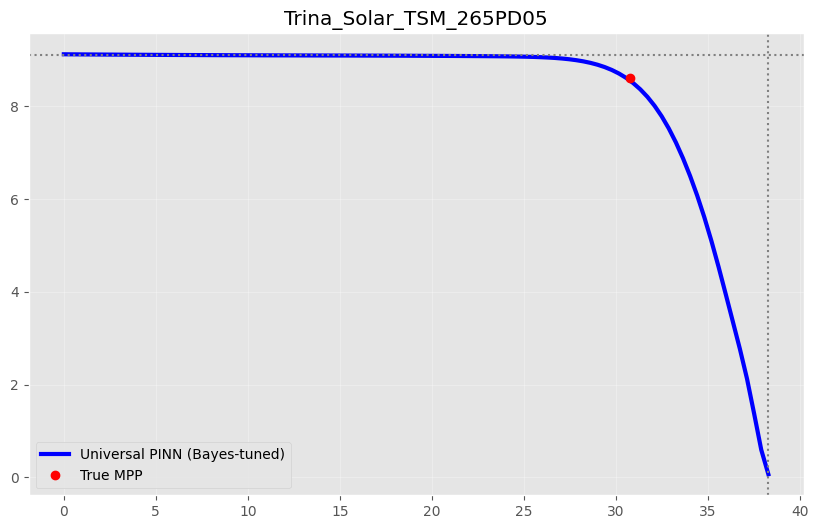

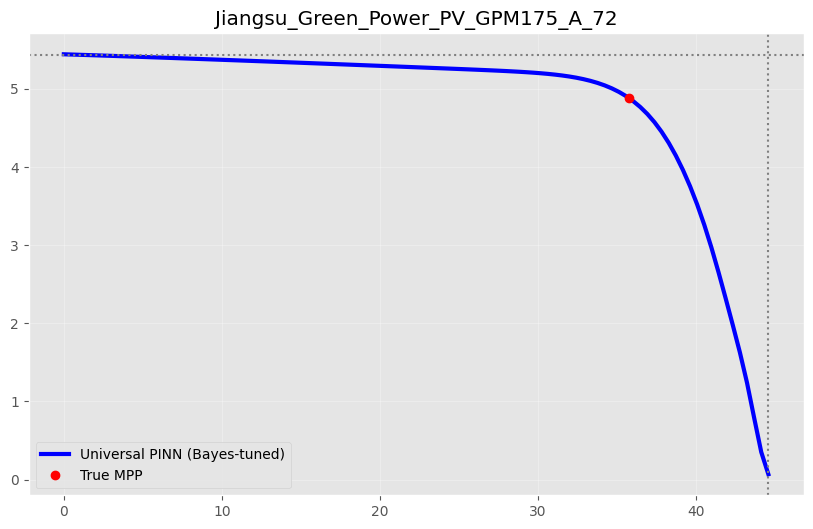

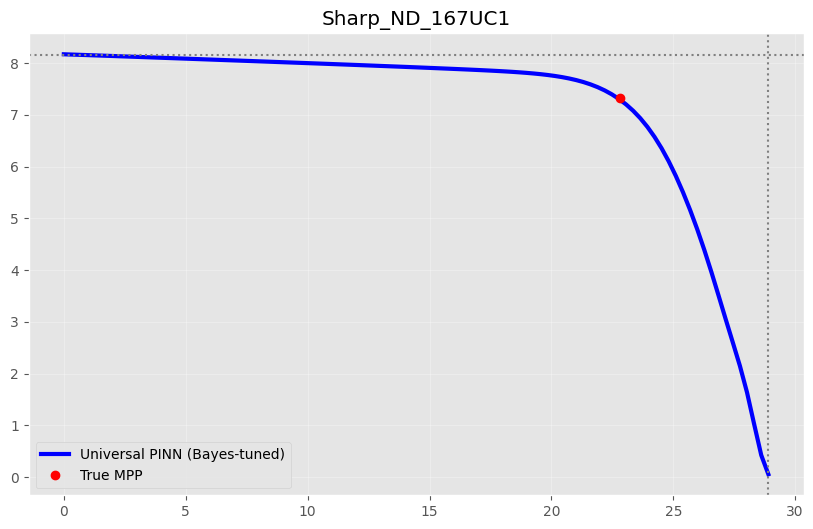

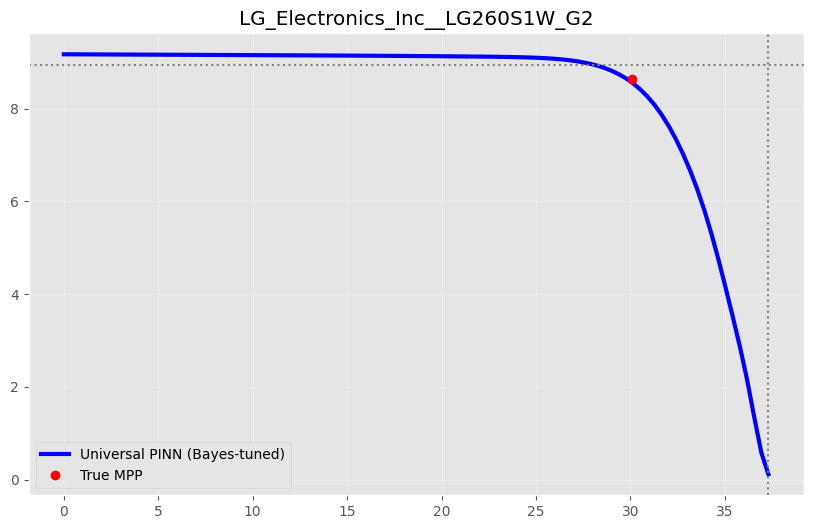

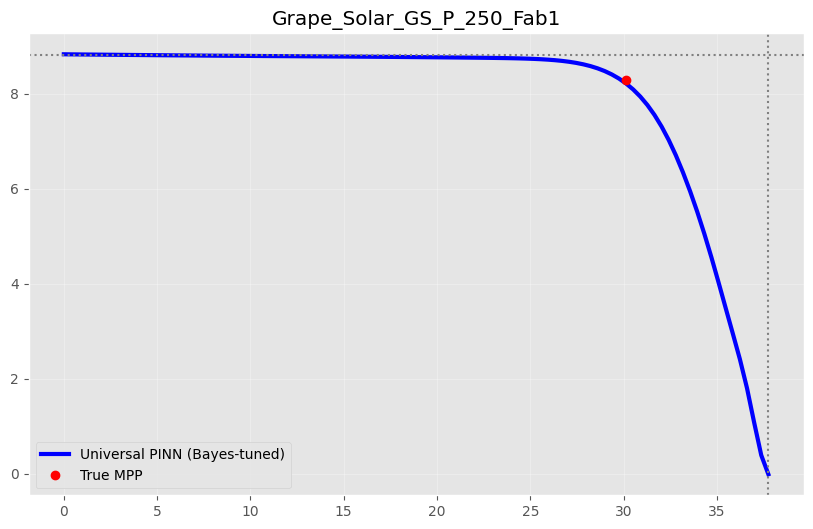

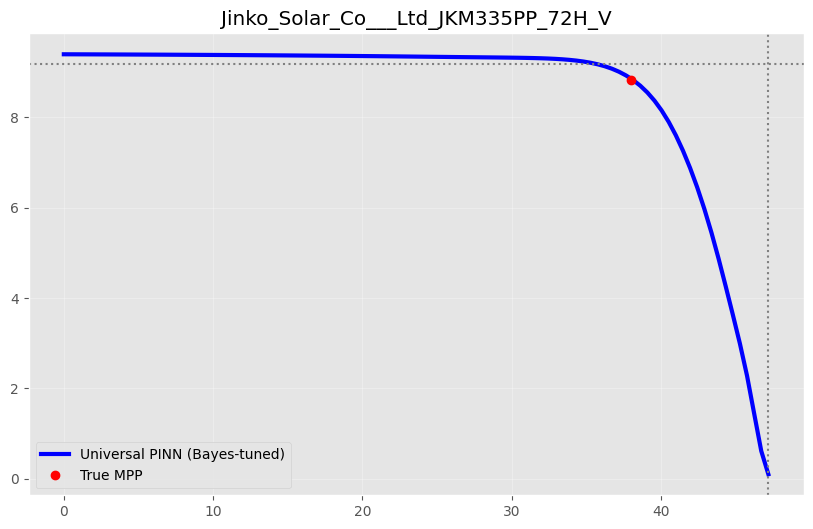

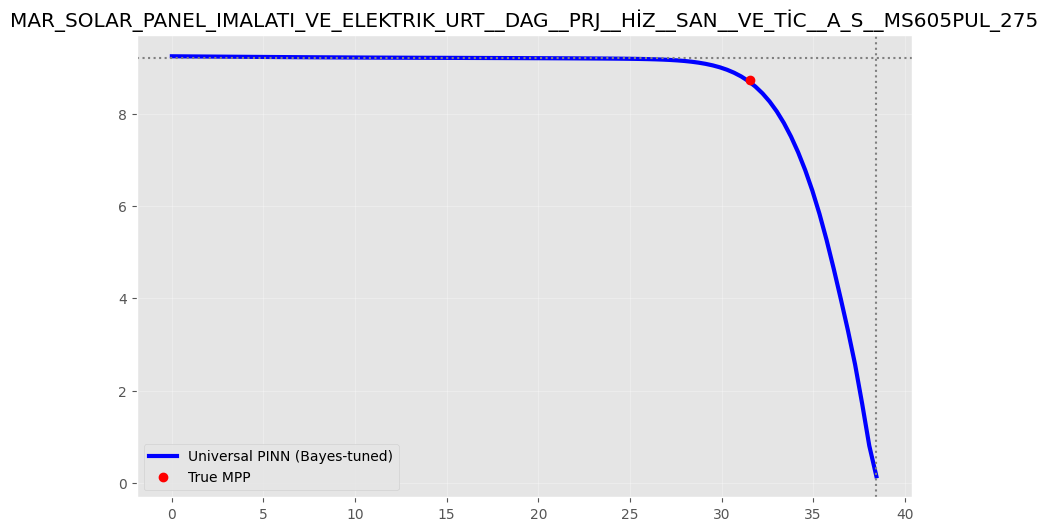

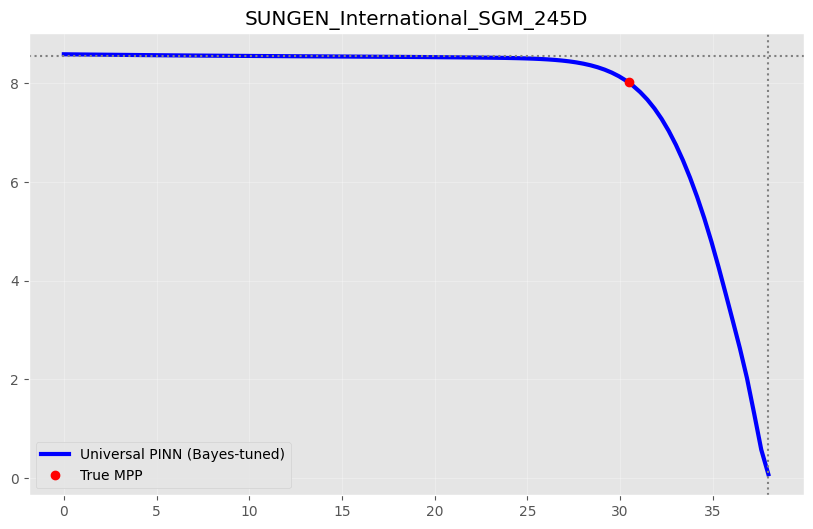

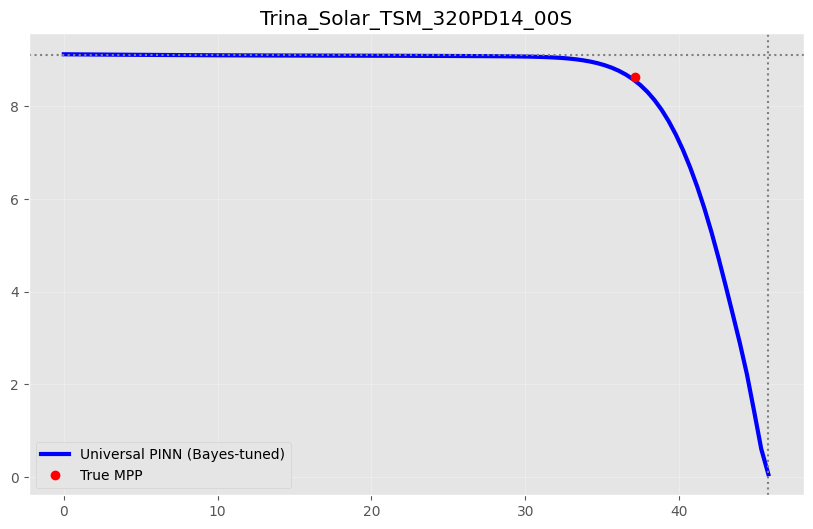

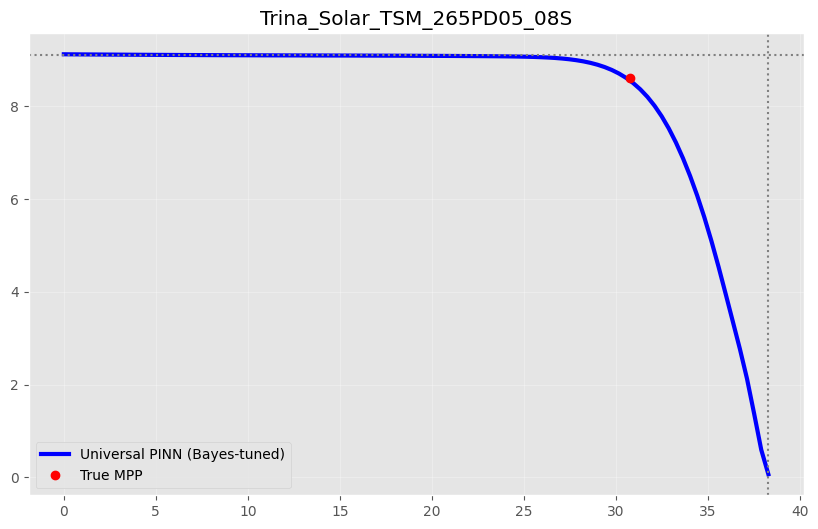

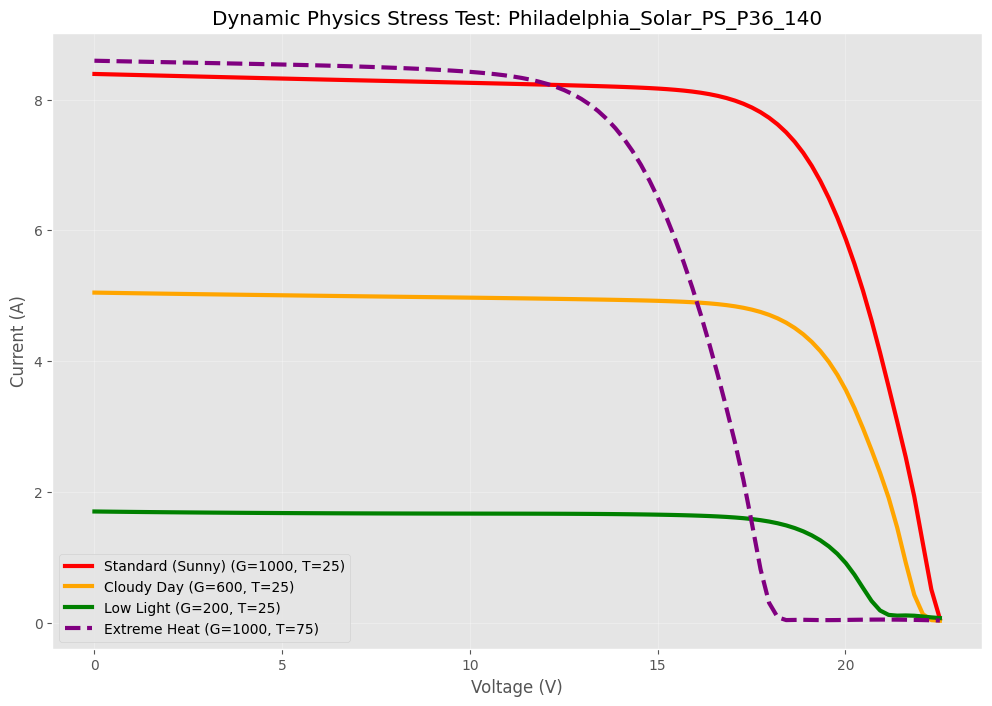

In [3]:
import pvlib
import pandas as pd

# Retrieve the CEC module database
# The result is a pandas DataFrame where module names are the index
cec_modules = pvlib.pvsystem.retrieve_sam('CECMod')

# To see all module names (the index of the DataFrame)
all_module_names = cec_modules.index.tolist()
print("Starting sampling test.......")
for i in range(10):
  test_panel(all_module_names[i])


def stress_test_physics(panel_name):
    try: row = df_db.loc[panel_name]
    except: row = df_db.sample(1).iloc[0]; panel_name = row.name

    # 1. Prepare DNA (Static for this panel)
    dna_vals = [row[c] for c in fit_cols]
    dna_df = pd.DataFrame([dna_vals], columns=fit_cols)
    dna_norm = dna_scaler.transform(dna_df)[0]
    
    # 2. Define 3 Scenarios
    scenarios = [
        {"G": 1000, "T": 25, "Label": "Standard (Sunny)", "Color": "red"},
        {"G": 600,  "T": 25, "Label": "Cloudy Day",       "Color": "orange"},
        {"G": 200,  "T": 25, "Label": "Low Light",        "Color": "green"},
        {"G": 1000, "T": 75, "Label": "Extreme Heat",     "Color": "purple"} # High T should drop Voltage
    ]
    
    plt.figure(figsize=(12, 8))
    
    v_sweep = np.linspace(0, 1.0, 100)
    
    for s in scenarios:
        # Build Inputs: [G_norm, T_norm, V_norm, DNA..., Scalers...]
        X_test = []
        for v in v_sweep:
            X_test.append([
                s["G"]/1000.0,      # G_norm
                (s["T"]-25.0)/100.0,# T_norm
                v                   # Voltage Sweep
            ] + dna_norm.tolist() + [
                row['V_oc_ref']/50.0, 
                row['I_sc_ref']/10.0
            ])
            
        # Predict
        y_pred = model.predict(np.array(X_test, dtype='float32'), verbose=0)
        
        # Denormalize
        I_pred = y_pred.flatten() * row['I_sc_ref']
        V_real = v_sweep * row['V_oc_ref']
        
        # Plot
        style = '--' if s["T"] > 25 else '-'
        plt.plot(V_real, I_pred, label=f"{s['Label']} (G={s['G']}, T={s['T']})", 
                 color=s['Color'], lw=3, linestyle=style)

    plt.title(f"Dynamic Physics Stress Test: {panel_name}")
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current (A)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Test on a random panel
stress_test_physics(df_db.sample(1).index[0])

🚀 STARTING MASSIVE BENCHMARK: 1000 PANELS
Simulating full day for 1000 panels... (Physics vs. PINN)
Processing panel 0/1000...
Processing panel 20/1000...
Processing panel 40/1000...
Processing panel 60/1000...
Processing panel 80/1000...
Processing panel 100/1000...
Processing panel 120/1000...
Processing panel 140/1000...
Processing panel 160/1000...
Processing panel 180/1000...
Processing panel 200/1000...
Processing panel 220/1000...
Processing panel 240/1000...
Processing panel 260/1000...
Processing panel 280/1000...
Processing panel 300/1000...
Processing panel 320/1000...
Processing panel 340/1000...
Processing panel 360/1000...
Processing panel 380/1000...
Processing panel 400/1000...
Processing panel 420/1000...
Processing panel 440/1000...
Processing panel 460/1000...
Processing panel 480/1000...
Processing panel 500/1000...
Processing panel 520/1000...
Processing panel 540/1000...
Processing panel 560/1000...
Processing panel 580/1000...
Processing panel 600/1000...
Process

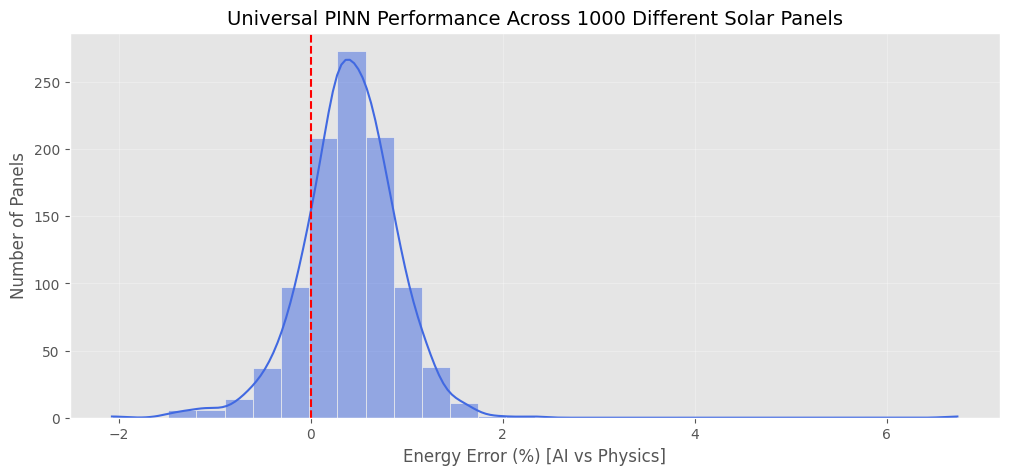

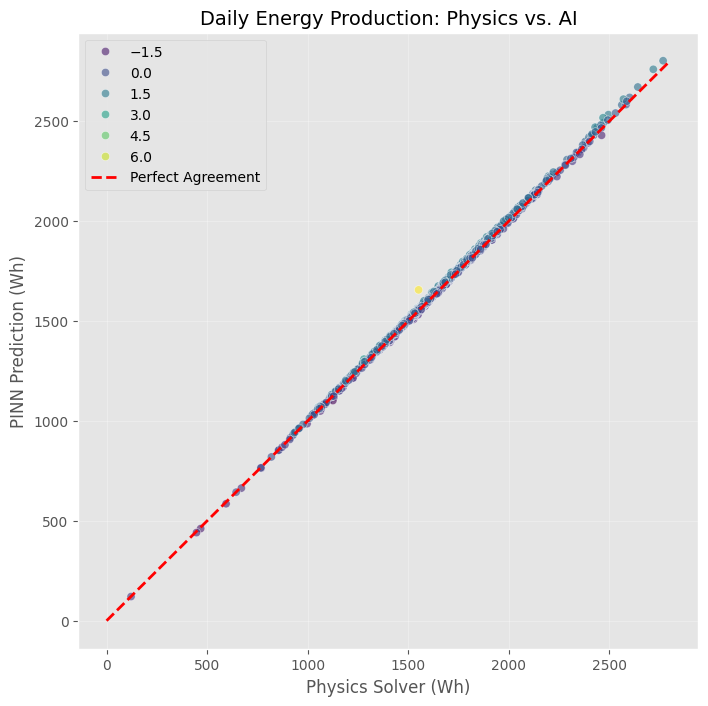


       FINAL SCORECARD       
Panels Tested:      1000
Mean Abs Error:     0.52%
Median Abs Error:   0.46%
95th Percentile:    1.19%


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pvlib import pvsystem

# 1. Suppress the specific Scipy/Numpy warnings that clutter the output
warnings.filterwarnings('ignore', category=RuntimeWarning, module='scipy.optimize')
warnings.filterwarnings('ignore', category=RuntimeWarning, module='numpy')

def run_massive_benchmark(trained_model, n_panels=200):
    print("="*60)
    print(f"🚀 STARTING MASSIVE BENCHMARK: {n_panels} PANELS")
    print("="*60)
   
    # 1. Select Random Panels
    # Ensure we only pick valid rows from the CEC database
    test_indices = np.random.choice(len(df_db), n_panels, replace=False)
   
    # 2. Define the "Test Day" Weather (Same for all panels)
    times = pd.date_range('2025-06-21 06:00', '2025-06-21 18:00', freq='15min')
    N_t = len(times)
   
    # Create weather signals
    x = np.linspace(0, np.pi, N_t)
    g_signal = 1000 * np.sin(x)
    g_signal[20:26] *= 0.4  # Noon cloud
    
    # STABILITY FIX: PVLib solvers can fail at exactly 0 irradiance. 
    # We use a tiny floor (0.1W) for physics calculations.
    g_physics = np.maximum(g_signal, 0.1) 
    
    t_signal = 20 + 30 * np.sin(x) # Simple temp curve (20C to 50C)
   
    # 3. STORAGE FOR RESULTS
    results = []
   
    print(f"Simulating full day for {n_panels} panels... (Physics vs. PINN)")
   
    for i, idx in enumerate(test_indices):
        if i % 20 == 0: print(f"Processing panel {i}/{n_panels}...")
       
        row = df_db.iloc[idx]
        panel_name = row.name
       
        # --- A. PREPARE DNA ---
        dna_vals = [row[c] for c in fit_cols]
        dna_df = pd.DataFrame([dna_vals], columns=fit_cols)
        dna_norm = dna_scaler.transform(dna_df)[0]
       
        # --- B. CALCULATE TRUE ENERGY (PVLIB) ---
        energy_true = 0
        try:
            # We wrap the solver in errstate to ignore the 'divide by zero' warnings 
            # produced by internal Scipy iterations
            with np.errstate(divide='ignore', invalid='ignore'):
                IL, I0, Rs, Rsh, nNsVth = pvsystem.calcparams_desoto(
                    g_physics, t_signal,
                    row['alpha_sc'], row['a_ref'], row['I_L_ref'],
                    row['I_o_ref'], row['R_sh_ref'], row['R_s']
                )
                
                # Solve for max power point using LambertW
                sol = pvsystem.singlediode(IL, I0, Rs, Rsh, nNsVth, method='lambertw')
                p_mp = sol['p_mp']
                
                # Clean up results (replace NaNs with 0)
                p_mp_clean = np.nan_to_num(p_mp, nan=0.0)
                energy_true = np.sum(p_mp_clean) * 0.25 # 15 min intervals = 0.25 hours
        except Exception:
            continue # Skip panels that cause the physics solver to diverge
           
        if energy_true < 5: continue # Skip broken/tiny panels
           
        # --- C. CALCULATE AI ENERGY (PINN) ---
        # Generate Voltage Sweep [0 to 1 normalized]
        v_res = 50
        v_sweep = np.linspace(0, 1.0, v_res)
       
        # Build Vectorized Batch: [Time * Voltage Sweep, Features]
        G_flat = np.repeat(g_signal/1000.0, v_res)
        T_flat = np.repeat((t_signal-25.0)/100.0, v_res)
        V_flat = np.tile(v_sweep, N_t)
       
        DNA_flat = np.tile(dna_norm, (len(G_flat), 1))
        # SC characteristics for scaling the PINN output
        SC_flat = np.tile([row['V_oc_ref']/50.0, row['I_sc_ref']/10.0], (len(G_flat), 1))
       
        X_batch = np.column_stack([G_flat, T_flat, V_flat, DNA_flat, SC_flat])
       
        # Run AI Inference (Batch process the entire day at once)
        y_pred = trained_model.predict(X_batch, batch_size=8192, verbose=0).flatten()
       
        # Convert AI normalized current back to Power
        i_real = y_pred * row['I_sc_ref']
        v_real = V_flat * row['V_oc_ref']
        p_real = v_real * i_real
       
        # Find peak power for each of the 48 time steps
        p_matrix = p_real.reshape(N_t, v_res)
        ai_p_mp = np.max(p_matrix, axis=1) 
       
        energy_ai = np.sum(ai_p_mp) * 0.25
       
        # --- D. COMPARE ---
        error_pct = (energy_ai - energy_true) / energy_true * 100
       
        results.append({
            "Name": panel_name,
            "Cells": row['N_s'],
            "True_Wh": energy_true,
            "AI_Wh": energy_ai,
            "Error_%": error_pct
        })

    # 4. VISUALIZATION
    df_res = pd.DataFrame(results)
    
    # Filter extreme outliers usually caused by physical solver failures
    df_res = df_res[df_res['Error_%'].abs() < 50]
   
    # Plot 1: Accuracy Distribution
    plt.figure(figsize=(12, 5))
    sns.histplot(df_res['Error_%'], kde=True, color='royalblue', bins=30)
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f"Universal PINN Performance Across {len(df_res)} Different Solar Panels", fontsize=14)
    plt.xlabel("Energy Error (%) [AI vs Physics]", fontsize=12)
    plt.ylabel("Number of Panels", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()
   
    # Plot 2: Regression Correlation
    plt.figure(figsize=(8, 8))
    sns.scatterplot(data=df_res, x='True_Wh', y='AI_Wh', hue='Error_%', palette='viridis', alpha=0.6)
   
    max_val = max(df_res['True_Wh'].max(), df_res['AI_Wh'].max())
    plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Agreement')
   
    plt.title("Daily Energy Production: Physics vs. AI", fontsize=14)
    plt.xlabel("Physics Solver (Wh)", fontsize=12)
    plt.ylabel("PINN Prediction (Wh)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
   
    # 5. FINAL STATS
    mae = df_res['Error_%'].abs().mean()
    print("\n" + "="*30)
    print("       FINAL SCORECARD       ")
    print("="*30)
    print(f"Panels Tested:      {len(df_res)}")
    print(f"Mean Abs Error:     {mae:.2f}%")
    print(f"Median Abs Error:   {df_res['Error_%'].abs().median():.2f}%")
    print(f"95th Percentile:    {df_res['Error_%'].abs().quantile(0.95):.2f}%")
    print("="*30)
   
    return df_res

# RUN THE BENCHMARK
# Note: Ensure 'model', 'df_db', 'fit_cols', and 'dna_scaler' are defined in your workspace.
benchmark_results = run_massive_benchmark(model, n_panels=1000)

🚀 STARTING BATCH SIMULATION FOR 10 PANELS

[1/10] Simulating: Upsolar_UP_Z250MT_B
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 98.88%


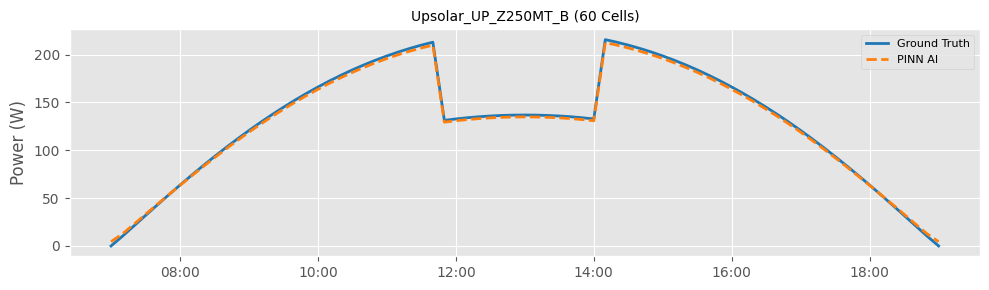


[2/10] Simulating: SunEdison_SE_F280GzD_4y
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 100.53%


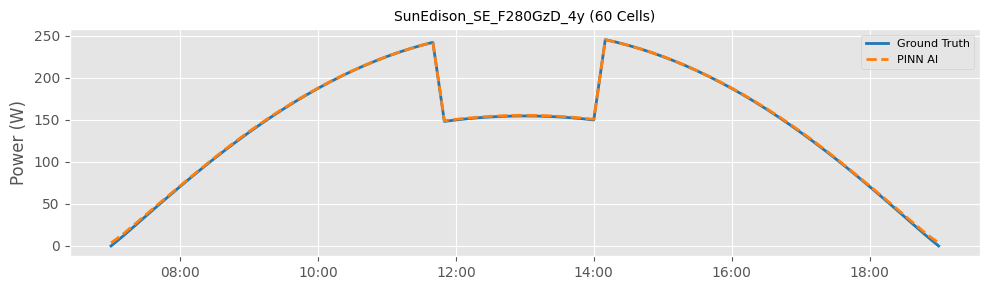


[3/10] Simulating: Chint_Solar__Zhejiang__Co___Ltd_CHSM6610P_275
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 100.17%


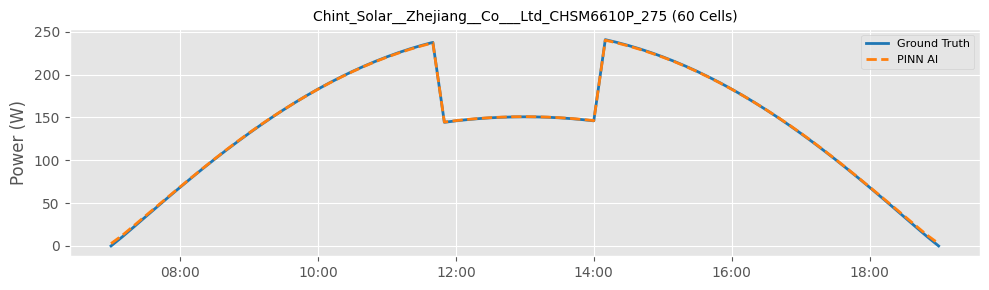


[4/10] Simulating: Topsun_TS_S385SA1
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 100.52%


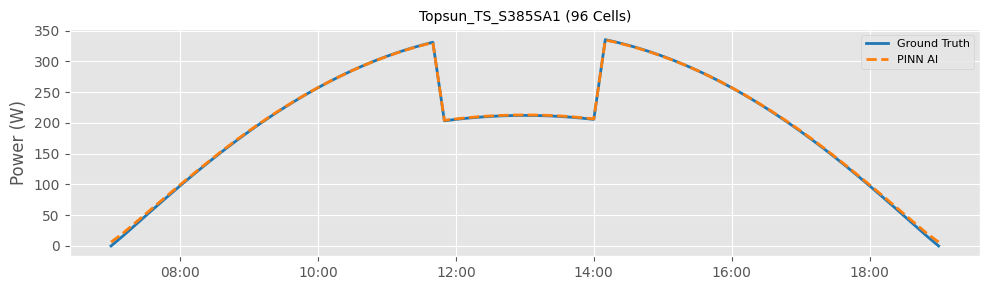


[5/10] Simulating: Jiangsu_SunLink_PV_Technology_SL280_24P285
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 100.68%


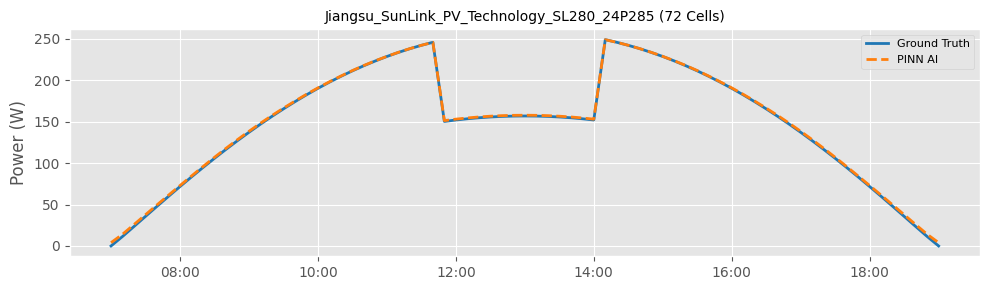


[6/10] Simulating: WAAREE_ENERGIES_LIMITED_WSM_340
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 100.83%


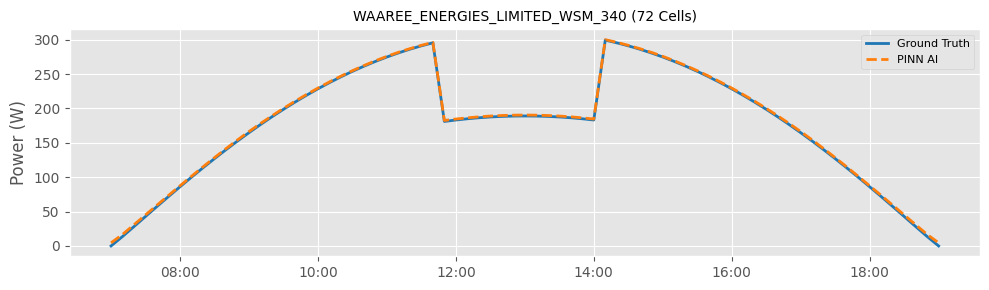


[7/10] Simulating: REC_Solar_REC235PE_BLK__ECO
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 100.38%


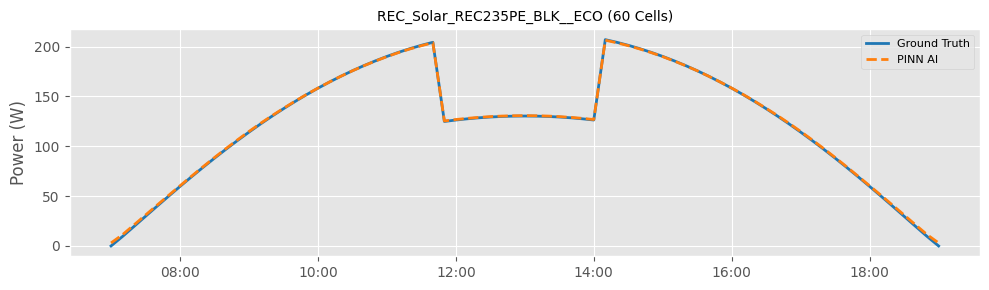


[8/10] Simulating: LG_Electronics_Inc__LG330E1C_A5
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 99.75%


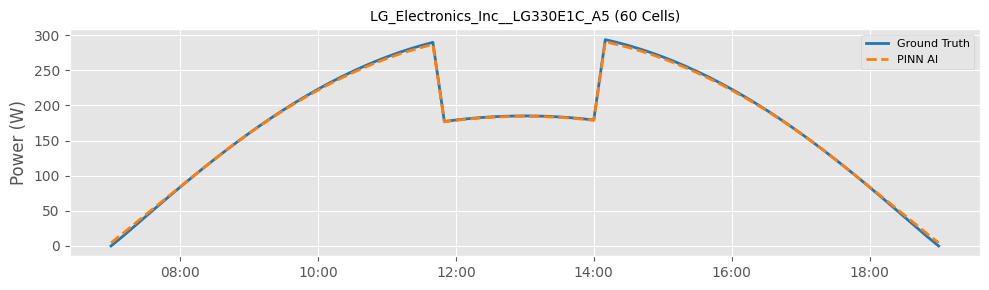


[9/10] Simulating: DuraComm_DCS_6P_48_185
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 100.01%


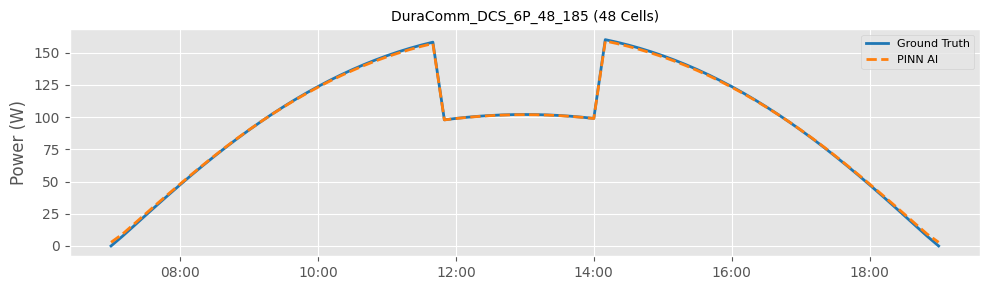


[10/10] Simulating: General_Energy_Solutions_7C00_6A240
------------------------------------------------------------
PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED
Batch predicting 7300 points...
Efficiency: 100.71%


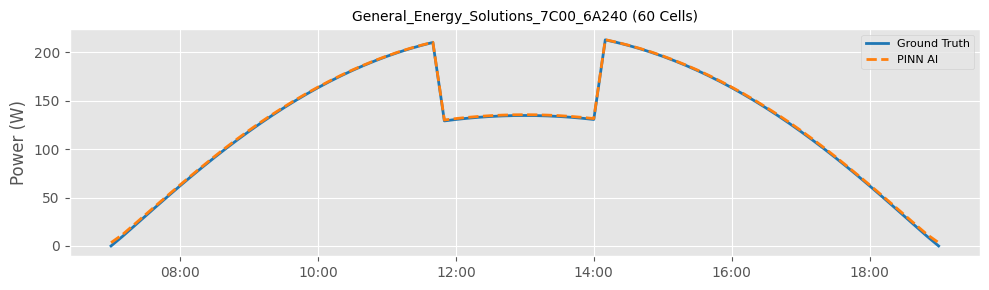

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pvlib
from pvlib import pvsystem
import seaborn as sns

def run_10_panel_simulation(trained_model, df_db, fit_cols, dna_scaler):
    # 1. Select 10 Random Panels
    # We try to get a mix of different cell counts if possible
    random_indices = np.random.choice(len(df_db), 10, replace=False)
    
    print(f"🚀 STARTING BATCH SIMULATION FOR 10 PANELS")
    
    for i, idx in enumerate(random_indices):
        row = df_db.iloc[idx]
        panel_name = row.name
        
        print(f"\n[{i+1}/10] Simulating: {panel_name}")
        print("-" * 60)

        # =====================================================================
        # A. PREPARE DNA
        # =====================================================================
        dna_vals = [row[c] for c in fit_cols]
        dna_df = pd.DataFrame([dna_vals], columns=fit_cols)
        dna_norm = dna_scaler.transform(dna_df)[0]

        # =====================================================================
        # B. WEATHER PROFILE (THE "NOTCH")
        # =====================================================================
        times = pd.date_range('2025-07-01 07:00', '2025-07-01 19:00', freq='10min')
        N_t = len(times)

        x = np.linspace(0, np.pi, N_t)
        g_signal = 1000 * np.sin(x)
        
        # Create the visual "Notch" (Cloud)
        start_notch = int(N_t * 0.40)
        end_notch = int(N_t * 0.60)
        g_signal[start_notch:end_notch] *= 0.6
        g_signal = np.clip(g_signal, 0, None)
        
        t_signal = 25 + 20 * np.sin(x)

        # =====================================================================
        # C. AI PREDICTION
        # =====================================================================
        v_res = 100
        v_sweep = np.linspace(0, 1.0, v_res)

        G_flat = np.repeat(g_signal / 1000.0, v_res)
        T_flat = np.repeat((t_signal - 25.0) / 100.0, v_res)
        V_flat = np.tile(v_sweep, N_t)
        DNA_flat = np.tile(dna_norm, (len(G_flat), 1))
        SC_flat = np.tile([row['V_oc_ref']/50.0, row['I_sc_ref']/10.0], (len(G_flat), 1))

        X_batch = np.column_stack([G_flat, T_flat, V_flat, DNA_flat, SC_flat])

        print(f"PVLIB DYNAMIC SIMULATION — FULLY VECTORIZED")
        print(f"Batch predicting {len(X_batch)} points...")

        # Predict
        y_pred = trained_model.predict(X_batch, batch_size=8192, verbose=0).flatten()

        # Denormalize
        i_pred = y_pred * row['I_sc_ref']
        v_real = V_flat * row['V_oc_ref']
        p_pred = v_real * i_pred
        
        # Get Max Power
        p_matrix = p_pred.reshape(N_t, v_res)
        ai_p_mp = np.max(p_matrix, axis=1)

        # =====================================================================
        # D. PHYSICS VERIFICATION
        # =====================================================================
        true_p_mp = []
        
        # Calculate params (Vectorized)
        IL, I0, Rs, Rsh, nNsVth = pvsystem.calcparams_desoto(
            g_signal, t_signal, 
            row['alpha_sc'], row['a_ref'], row['I_L_ref'], 
            row['I_o_ref'], row['R_sh_ref'], row['R_s']
        )
        
        # Solve Singlediode (Loop for safety)
        for k in range(N_t):
            if g_signal[k] < 10: 
                true_p_mp.append(0)
                continue
            try:
                res = pvsystem.singlediode(
                    IL[k], I0[k], Rs[k], Rsh[k], nNsVth[k], method='lambertw'
                )
                true_p_mp.append(res['p_mp'])
            except:
                true_p_mp.append(0)

        # Efficiency
        total_ai = np.sum(ai_p_mp)
        total_true = np.sum(true_p_mp)
        eff = (total_ai / total_true) * 100

        print(f"Efficiency: \033[1m{eff:.2f}%\033[0m") 

        # =====================================================================
        # E. PLOTTING
        # =====================================================================
        fig, ax = plt.subplots(figsize=(10, 3))
        
        ax.plot(times, true_p_mp, label='Ground Truth', color='#1f77b4', lw=2)
        ax.plot(times, ai_p_mp, label='PINN AI', color='#ff7f0e', linestyle='--', lw=2)
        
        ax.set_title(f"{panel_name} ({int(row['N_s'])} Cells)", fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.set_ylabel("Power (W)")
        
        plt.legend(loc='upper right', fontsize=8)
        plt.tight_layout()
        plt.show()

# Run the Batch
run_10_panel_simulation(model, df_db, fit_cols, dna_scaler)